# Lag Design

In [ ]:
# Course utilities (do not modify this cell)

from pathlib import Path
import sys

# repo_root/16_06_Class/notebooks → repo_root/16_06_Class
repo_root = Path.cwd().parents[0]
sys.path.insert(0, str(repo_root))

import courseutils.basic_material as bm
import courseutils.control_materials as cm

bm.setup_environment()
cm.setup_environment()

import numpy as np
import matplotlib.pyplot as plt
colors = bm.get_colors()

from scipy.optimize import fsolve


In [26]:
colors = bm.get_colors()

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

import control as ct
import control.matlab as cmat

import warnings
warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in divide"
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide"
)

source = "./"

# RL Lag Design 10-25

In [27]:
# System
G = ct.tf((0, 10), np.convolve((1,0),np.convolve((1,5),(1,10))))
# Goals
Mp = 0.2
Ts = 4 # 2%

# Target Poles
zeta = np.sqrt(np.log(Mp)**2/(np.pi**2+np.log(Mp)**2))
wn = 4/zeta/Ts # 2%
wd = wn*np.sqrt(1-zeta**2)

s0 = np.roots([1, 2*zeta*wn, wn**2])
cm.pretty_row_print(s0, msg="Target Poles: " )
print(f"Target {zeta= :.3f}")
print(f"Target {wn= :.3f}")
print(f"Target {wd= :.3f}")

Target Poles: (-1.00 + 1.95i), (-1.00 + -1.95i)
Target zeta= 0.456
Target wn= 2.193
Target wd= 1.952


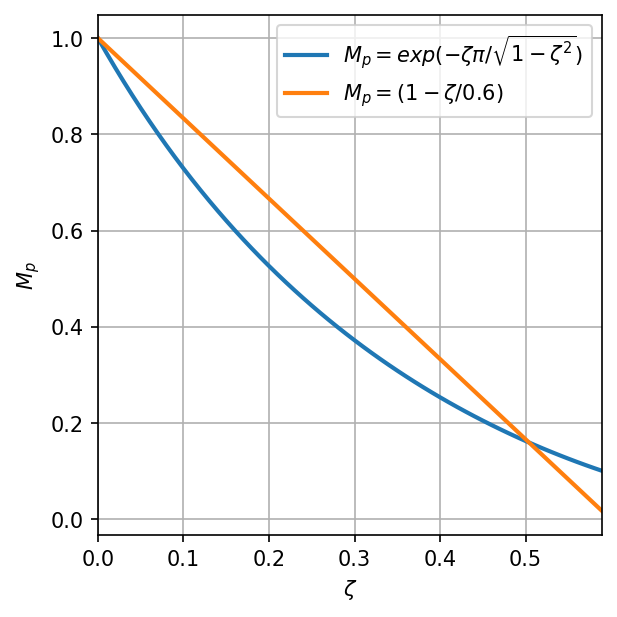

In [28]:
# Check the approximate Mp specification
fig, ax = plt.subplots(figsize=(4, 4),dpi=150,constrained_layout = True)
Zeta = np.arange(0,0.6,1/100)
plt.plot(Zeta,np.exp(-Zeta*np.pi/np.sqrt(1-Zeta**2)),label=r'$M_p = exp(-\zeta\pi/\sqrt{1-\zeta^2})$')
plt.plot(Zeta,(1-Zeta/0.6),label=r'$M_p = (1-\zeta/0.6)$')
plt.xlabel(r'$\zeta$')
plt.ylabel(r'$M_p$')
plt.legend()
plt.show()

Target Poles: (-1.00 + 1.95i), (-1.00 + -1.95i)
Closed-loop poles with K=13: -11.670, (-1.66 + 2.89i), (-1.66 + -2.89i)


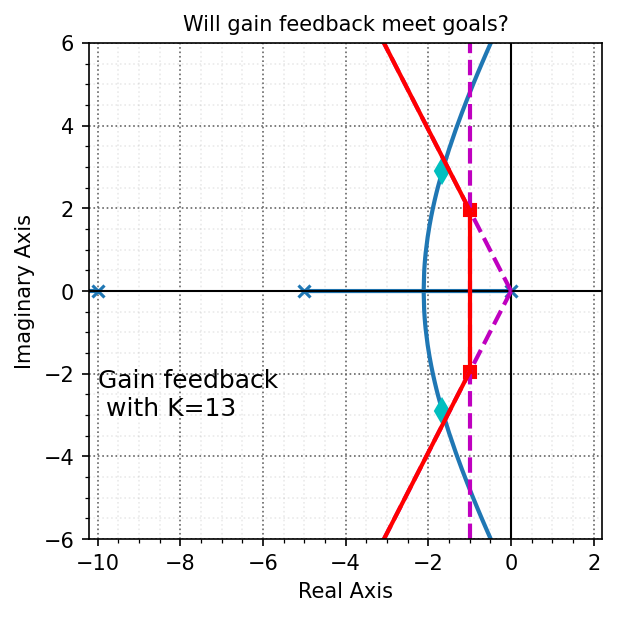

array([   2.193,    2.193])

In [29]:
Kdesign = 13 # gain to place the root locus near the target poles at the start of the lag design

fig, ax = plt.subplots(figsize=(4, 4),dpi=150,constrained_layout = True)
ct.rlocus(G,ax=ax)
scl = ct.feedback(G,Kdesign).poles()
cm.pretty_row_print(s0, msg="Target Poles: " )
cm.pretty_row_print(scl, msg=f"Closed-loop poles with K={Kdesign}: " )

ax.plot(s0.real,s0.imag,'rs',ms=6)
ax.plot(scl.real,scl.imag,'cd',ms=8)
ax.axis('equal')
ax.set_xlim([-10, 2])
ax.set_ylim([-6, 6])
ax.set_title('Root Locus for P')
bm.nicegrid(ax)
ax.set_xlabel('Real Axis')
ax.set_ylabel('Imaginary Axis')
cm.plot_spec_region(ax, zeta, wn, wd)

plt.title("Will gain feedback meet goals?")
ax.text(-10, -3, f"Gain feedback\n with K={Kdesign}", fontsize=12)
plt.savefig("./figs/L12_RL_des1.pdf", dpi=600)
plt.show()
np.abs(s0)

# Lag Design on 10-28

In [30]:
# Lag Design
Kv_req = 1/0.05
gamma = 10 # design choice
b = np.real(abs(s0[0])/gamma)
Kv_G = cm.find_Kv(G)
a =  b/(Kv_req/(Kv_G*Kdesign))
Gc_lag = Kdesign*ct.tf((1, b), (1, a))
L = Gc_lag*G

In [31]:
print(f"Gain = {cm.hf_gain(Gc_lag) :.3f}")
print(f"Lag zero s = {-b :.3f}")
print(f"Lag pole s = {-a :.3f}")

cm.show_tf_latex(Gc_lag,show=True,label="G_c(s)",factor=True,sigfigs=3)
msgs = cm.show_tf_latex(Gc_lag,label="G_c(s)",factor=True,sigfigs=3)

Gain = 13.000
Lag zero s = -0.219
Lag pole s = -0.029


<IPython.core.display.Math object>


Found break-in/out at K =  0.409
At possible locations s = -1.960

Found break-in/out at K =  0.275
At possible locations s = -0.458

Found break-in/out at K =  0.000
At possible locations s = -0.015

Found break-in/out at K =  0.409
At possible locations s = -1.960

Found break-in/out at K =  0.275
At possible locations s = -0.458

Found break-in/out at K =  0.000
At possible locations s = -0.015


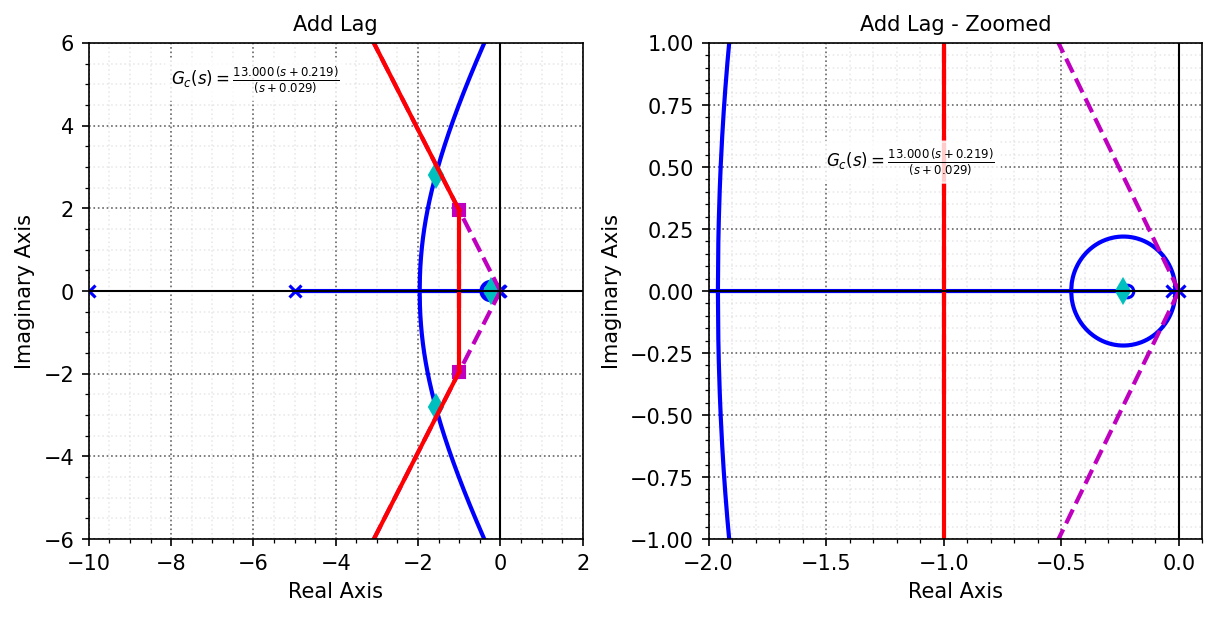

In [32]:
def plot_rlocus_panel(ax, L, s0, zeta, wn, wd,
                      xlim, ylim,
                      title="",
                      show_text=None):

    # root locus
    ct.rlocus(L, gains=cm.Root_Locus_gains(L), ax=ax, color='blue')

    scl = ct.feedback(L).poles()
    ax.plot(s0.real, s0.imag, 'ms', ms=6)
    ax.plot(scl.real, scl.imag, 'cd', ms=8)

    cm.plot_spec_region(ax, zeta, wn, wd)

    # formatting
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_title(title)
    ax.set_xlabel("Real Axis")
    ax.set_ylabel("Imaginary Axis")
    bm.nicegrid(ax)

    if show_text:
        ax.text(*show_text,fontsize=8,color="black",
                bbox=dict(facecolor="white",edgecolor='white',boxstyle="round,pad=0.3",alpha=0.8))

fig, ax = plt.subplots(1,2,figsize=(8,4), dpi=150, constrained_layout=True)
plot_rlocus_panel(ax[0], L, s0, zeta, wn, wd,
                  xlim=[-10, 2],
                  ylim=[-6, 6],
                  title="Add Lag",
                  show_text=(-8, 5, msgs))

plot_rlocus_panel(ax[1], L, s0, zeta, wn, wd,
                  xlim=[-2, .1],
                  ylim=[-1, 1],
                  title="Add Lag - Zoomed",
                  show_text=(-1.5, 0.5, msgs))

def save_axis(ax, filename, pad=0.05):
    fig = ax.figure
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    bbox = ax.get_tightbbox(renderer)
    bbox = bbox.expanded(1 + pad,1 + pad)
    bbox = bbox.transformed(fig.dpi_scale_trans.inverted())

    fig.savefig(filename, bbox_inches=bbox)

save_axis(ax[0], "./figs/L12_RL_des1a.pdf", pad=0.03)
save_axis(ax[1], "./figs/L12_RL_des1a_zoomed.pdf", pad=0.03)


omega_n:	2.885
zeta   :	0.435
Tr     :	0.50s
Ts     :	3.64s
Mp     :	0.22
Tp     :	1.21s
Yss    :	1.02


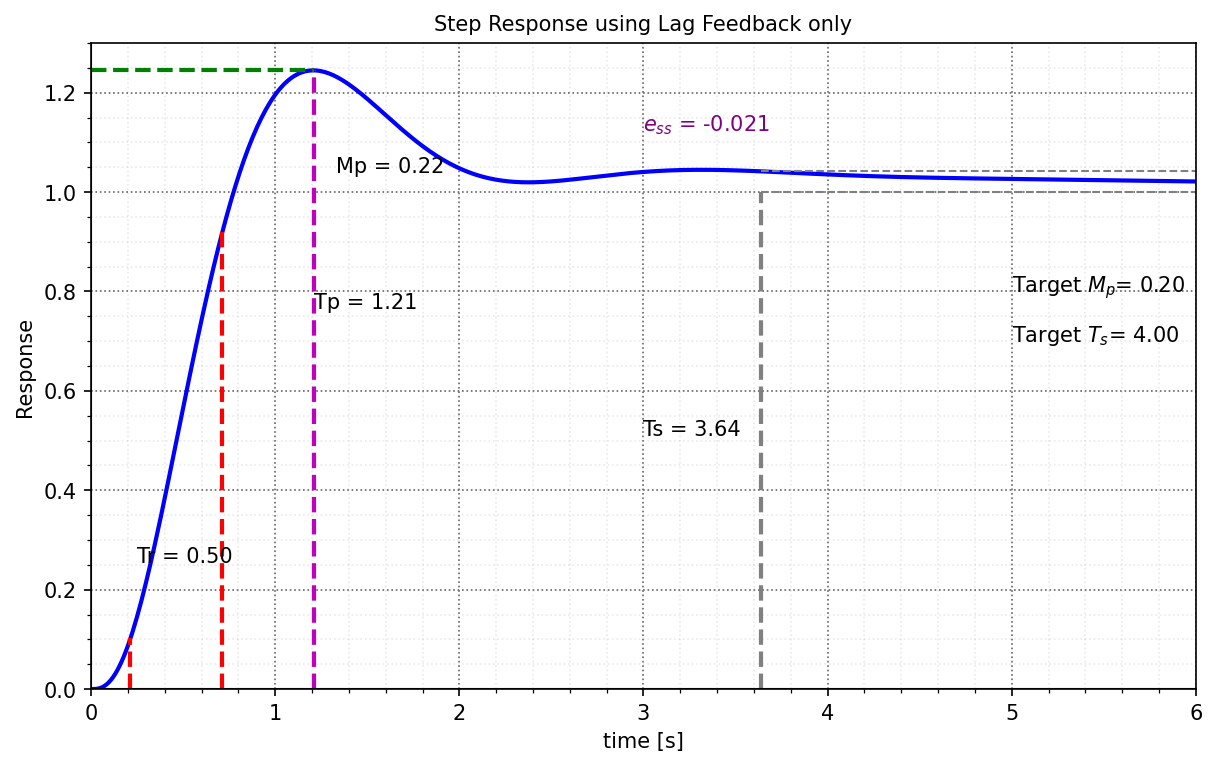

In [33]:
Gcl_lag = ct.feedback(L,1)
y_lag,t_lag = cmat.step(Gcl_lag,6)

fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150,constrained_layout = True)
S_lag = cm.Step_info(t_lag,y_lag)
S_lag.printout()
S_lag.nice_plot(ax)
bm.nicegrid(ax)
ax.text(Ts+1,0.8,f'Target $M_p$= {Mp:.2f}')
ax.text(Ts+1,0.7,f'Target $T_s$= {Ts:.2f}')
plt.title("Step Response using Lag Feedback only")
plt.savefig("./figs/L12_RL_des1b.pdf", dpi=600)
plt.show()

In [ ]:
t = np.linspace(0,60,1000)
u = t # for ramp input
y_lag_ramp, t_lag_ramp, _ = cmat.lsim(ct.ss(Gcl_lag), T=t, U=u)

fig, ax = plt.subplots(figsize=(8, 5),dpi=150,constrained_layout = True)
plt.plot(t_lag_ramp,y_lag_ramp,label='y')
plt.plot(t_lag_ramp,t_lag_ramp,label='ramp')
plt.plot(t_lag_ramp,100*(t_lag_ramp - y_lag_ramp),label='100*err')
plt.axhline(y=100/Kv_req,ls=':')
bm.nicegrid(ax)
plt.title("Ramp")
plt.xlabel("Time [s]")
plt.ylabel("Response")
plt.legend()
plt.title("Ramp using Lag Feedback only")
plt.savefig("./figs/L12_RL_des1c.pdf", dpi=600)
plt.show()

# Repeat RL Lag Design Above with tighter spec (10-29)

In [ ]:
G = ct.tf((0, 10), np.convolve((1,0),np.convolve((1,5),(1,10))))
Mp = 0.2
Ts = 1 # decreased from 4 in earlier design
Kv_req = 1/0.05
#
zeta = np.sqrt(np.log(Mp)**2/(np.pi**2+np.log(Mp)**2))
#
wn = 4/zeta/Ts # 2%
wd = wn*np.sqrt(1-zeta**2)
# Target Poles
s0 = np.roots([1, 2*zeta*wn, wn**2])
print(f"{zeta= :.3f}")
print(f"{wn= :.3f}")
print(f"{wd= :.3f}")
s0 = np.roots([1, 2*zeta*wn, wn**2])
cm.pretty_row_print(s0, msg="Target Poles: ")

zeta= 0.456
wn= 8.773
wd= 7.808
Target Poles: (-4.00 + 7.81i), (-4.00 + -7.81i)


Target Poles: (-4.00 + 7.81i), (-4.00 + -7.81i)
Closed-loop poles with K=13: -11.670, (-1.66 + 2.89i), (-1.66 + -2.89i)


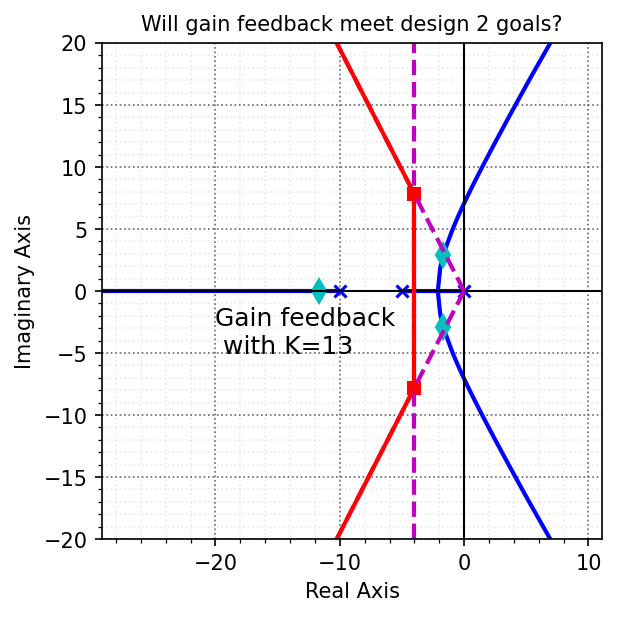

array([   8.773,    8.773])

In [ ]:
# Check if gain feedback can meet the specs for Design 2
fig, ax = plt.subplots(figsize=(4, 4),dpi=150,constrained_layout = True)
ct.rlocus(G,ax=ax,color='blue')
scl = ct.feedback(G*Kdesign).poles()
cm.pretty_row_print(s0, msg="Target Poles: " )
cm.pretty_row_print(scl, msg=f"Closed-loop poles with K={Kdesign}: " )

ax.plot(s0.real,s0.imag,'rs',ms=6)
ax.plot(scl.real,scl.imag,'cd',ms=8)
ax.axis('equal')
ax.set_xlim([-20, 2])
ax.set_ylim([-20, 20])
ax.set_title('Root Locus for P')
bm.nicegrid(ax)
ax.set_xlabel('Real Axis')
ax.set_ylabel('Imaginary Axis')

cm.plot_spec_region(ax, zeta, wn, wd)

plt.title("Will gain feedback meet design 2 goals?")
ax.text(-20, -5, f"Gain feedback\n with K={Kdesign}", fontsize=12)
plt.savefig("./figs/L12_RL_des2.pdf", dpi=600)
plt.show()
np.abs(s0)

In [ ]:
cm.pretty_row_print(s0, msg="Target Poles: " )
Gc_lead, scl,_ = cm.Root_Locus_design_cancel(G,s_target = s0[0], s_cancel = G.poles()[1].real)
print(f"{Gc_lead.dcgain() = :.3f}")
print(f"{Gc_lead.zeros()[0] = :.3f}")
print(f"{Gc_lead.poles()[0] = :.3f}")
L_lead = G*Gc_lead
Gc_lead
        
cm.write_tf_latex(Gc_lead, source+"Gc_10_33.tex", label="G^{lead}_c(s)", factor=True, sigfigs=3, inline=True)

Target Poles: (-4.00 + 7.81i), (-4.00 + -7.81i)
Gc_lead.dcgain() = 40.138
Gc_lead.zeros()[0] = -5.000+0.000j
Gc_lead.poles()[0] = -46.482+0.000j


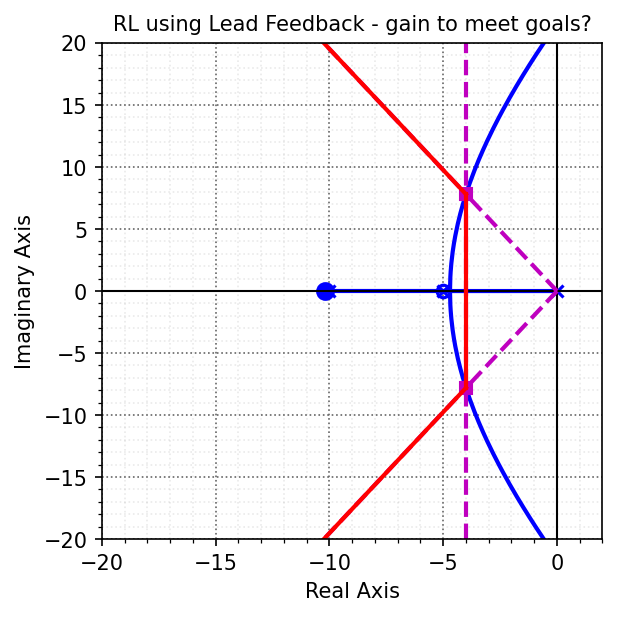

In [ ]:
fig, ax = plt.subplots(figsize=(4, 4),dpi=150,constrained_layout = True)
ct.rlocus(L_lead,ax=ax,color='blue')
scl = ct.feedback(G,1).poles()

ax.plot(s0.real,s0.imag,'ms',ms=6)
ax.plot(scl[0].real,scl[0].imag,'bo',ms=8)
ax.set_xlim([-20, 2])
ax.set_ylim([-20, 20])
ax.set_title('Root Locus Using Lead')
bm.nicegrid(ax)
ax.set_xlabel('Real Axis')
ax.set_ylabel('Imaginary Axis')

cm.plot_spec_region(ax, zeta, wn, wd)

plt.title("RL using Lead Feedback - gain to meet goals?")
plt.savefig("./figs/L12_RL_des2a.pdf", dpi=600)
plt.show()

In [ ]:
# Repeat lag Design with plant (G*Gc_lead)
Kv_req = 1/0.05
gamma = 30
b = abs(s0[0])/gamma
Kv_with_lead = cm.find_Kv(G*Gc_lead)
a =  b/(Kv_req/Kv_with_lead)
Gc_lag = ct.tf((1, b), (1, a))
L_lead_lag = L_lead*Gc_lag

cm.show_tf_latex(Gc_lag,r"G_{c}^{lag}(s)",show=True,factor=True,sigfigs=3)
cm.write_tf_latex(Gc_lag, source+"Gc_10_33a.tex", label="G^{lag}_c(s)", factor=True, sigfigs=3, inline=True)

<IPython.core.display.Math object>


Found break-in/out at K =  0.288
At possible locations s = -5.000

Found break-in/out at K =  0.288
At possible locations s = -5.000

Found break-in/out at K =  0.290
At possible locations s = -4.591

Found break-in/out at K =  0.107
At possible locations s = -0.533

Found break-in/out at K =  0.002
At possible locations s = -0.066

Found break-in/out at K =  0.288
At possible locations s = -5.000

Found break-in/out at K =  0.288
At possible locations s = -5.000

Found break-in/out at K =  0.290
At possible locations s = -4.591

Found break-in/out at K =  0.107
At possible locations s = -0.533

Found break-in/out at K =  0.002
At possible locations s = -0.066


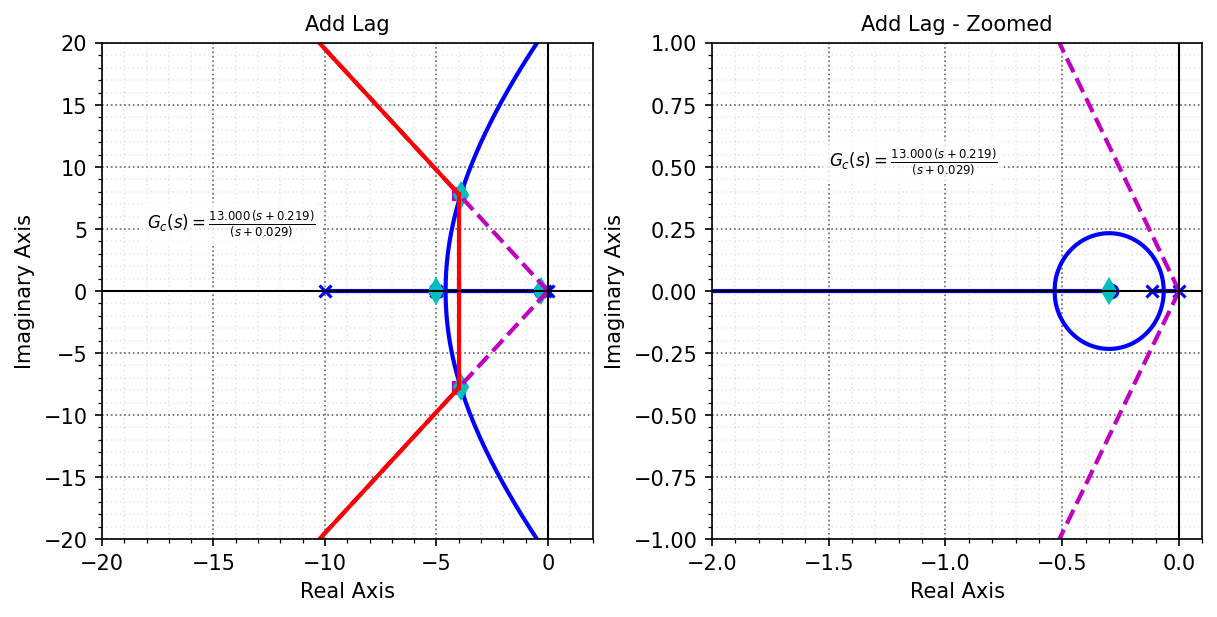

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(8,4), dpi=150, constrained_layout=True)
plot_rlocus_panel(ax[0], L_lead_lag, s0, zeta, wn, wd,
                  xlim=[-20, 2],
                  ylim=[-20, 20],
                  title="Add Lag",
                  show_text=(-18, 5, msgs))

plot_rlocus_panel(ax[1], L_lead_lag, s0, zeta, wn, wd,
                  xlim=[-2, .1],
                  ylim=[-1, 1],
                  title="Add Lag - Zoomed",
                  show_text=(-1.5, 0.5, msgs))

def save_axis(ax, filename, pad=0.05):
    fig = ax.figure
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    bbox = ax.get_tightbbox(renderer)
    bbox = bbox.expanded(1 + pad,1 + pad)
    bbox = bbox.transformed(fig.dpi_scale_trans.inverted())

    fig.savefig(filename, bbox_inches=bbox)

save_axis(ax[0], "./figs/L12_RL_des2aa.pdf", pad=0.03)
save_axis(ax[1], "./figs/L12_RL_des2aa_zoomed.pdf", pad=0.03)

omega_n:	8.187
zeta   :	0.440
Tr     :	0.18s
Ts     :	0.95s
Mp     :	0.21
Tp     :	0.43s
Yss    :	1.01


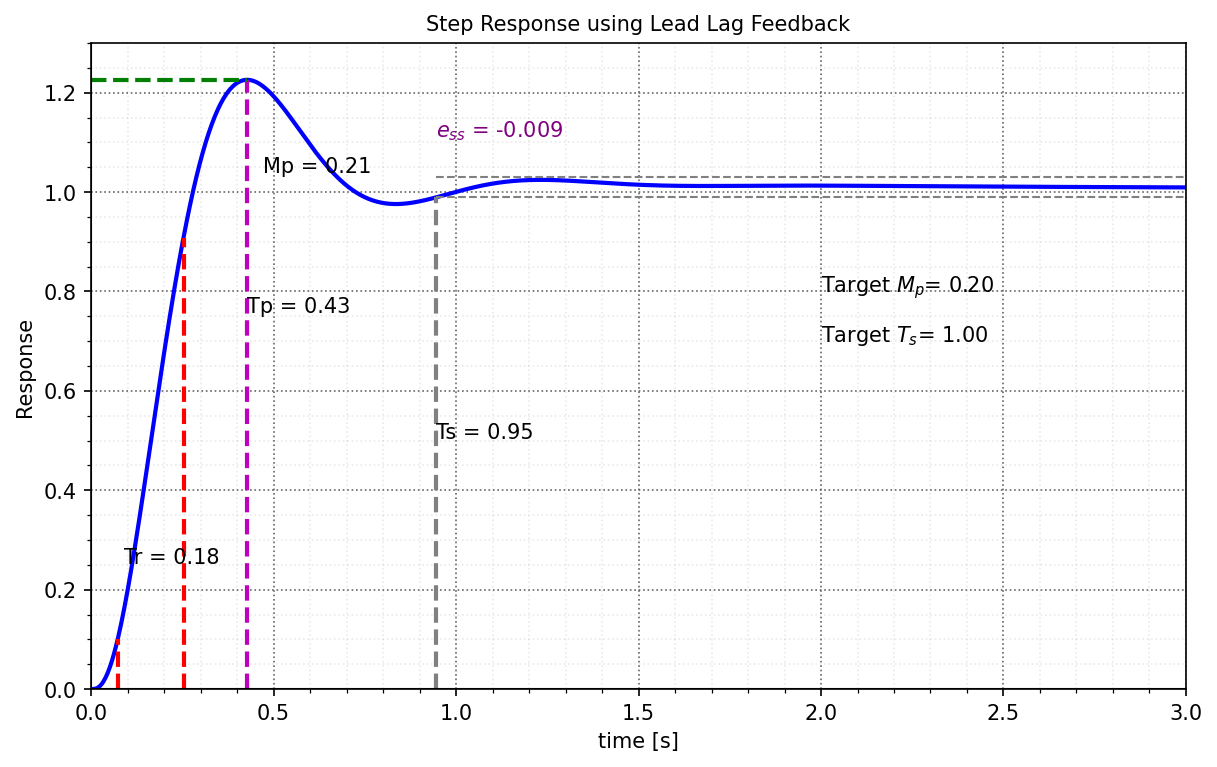

In [ ]:
Gcl_lead_lag = ct.feedback(L_lead_lag)
y_lead_lag,t_lead_lag = cmat.step(Gcl_lead_lag,3)

fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150,constrained_layout = True)
S_lead_lag = cm.Step_info(t_lead_lag,y_lead_lag)
S_lead_lag.printout()
S_lead_lag.nice_plot(ax)
bm.nicegrid(ax)
plt.title("Step Response using Lead Lag Feedback")
ax.text(Ts+1,0.8,f'Target $M_p$= {Mp:.2f}')
ax.text(Ts+1,0.7,f'Target $T_s$= {Ts:.2f}')
plt.savefig("./figs/L12_RL_des2b.pdf", dpi=600)
plt.show()

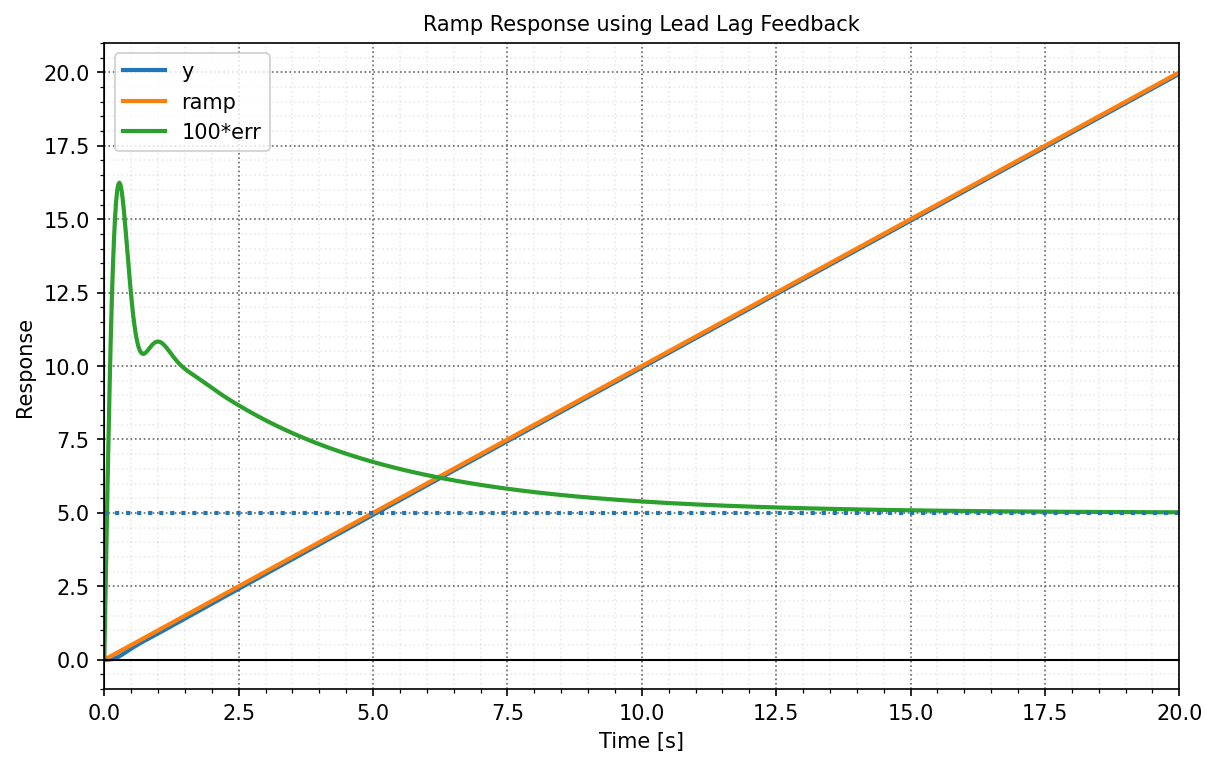

In [ ]:
t = np.linspace(0,20,1000)
y_lead_lag_ramp, t_lead_lag_ramp, x_lead_lag_ramp = cmat.lsim(ct.tf2ss(Gcl_lead_lag), T=t, U=t)

fig, ax = plt.subplots(figsize=(8, 5),dpi=150,constrained_layout = True)
plt.plot(t_lead_lag_ramp,y_lead_lag_ramp,label='y')
plt.plot(t_lead_lag_ramp,t_lead_lag_ramp,label='ramp')
plt.plot(t_lead_lag_ramp,100*(t_lead_lag_ramp - y_lead_lag_ramp),label='100*err')
plt.axhline(y=100/Kv_req,ls=':')
bm.nicegrid(ax)
plt.title("Ramp")
plt.xlabel("Time [s]")
plt.ylabel("Response")
plt.legend()
plt.title("Ramp Response using Lead Lag Feedback")
plt.savefig("./figs/L12_RL_des2c.pdf", dpi=600)
plt.show()